In [3]:
import numpy as np
import pandas as pd
import torch

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)

numpy: 1.26.4
pandas: 2.2.3
torch: 2.2.2


In [4]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import yfinance as yf
import ta

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [5]:
tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLV", "XLE", "XLI", "XLP", "XLU", "XLY", "XLB", "XLRE",
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "JPM", "XOM", "JNJ", "UNH", "PG"
]

start_date = "2012-01-01"
end_date = "2026-01-01"

len(tickers)

24

In [6]:
raw = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="ticker"
)

print(raw.shape)
raw.tail()

(3520, 120)


Ticker           XLRE                                                    XLB  \
Price            Open       High        Low      Close     Volume       Open   
Date                                                                           
2025-12-24  40.200001  40.509998  40.200001  40.439999  3242600.0  45.730000   
2025-12-26  40.349998  40.540001  40.308998  40.520000  5973000.0  45.950001   
2025-12-29  40.689999  40.740002  40.520000  40.630001  9519300.0  45.740002   
2025-12-30  40.630001  40.740002  40.560001  40.720001  7967100.0  45.810001   
2025-12-31  40.680000  40.689999  40.340000  40.349998  6082600.0  45.610001   

Ticker                                                ...          PG  \
Price            High        Low      Close   Volume  ...        Open   
Date                                                  ...               
2025-12-24  45.889999  45.610001  45.840000  2767600  ...  141.892557   
2025-12-26  46.139999  45.860001  46.110001  5035800  ...  143.292613   
2025-12-29  45.860001  45.540001  45.740002  6370400  ...  143.779171   
2025-12-30  45.849998  45.630001  45.730000  4432100  ...  143.272753   
2025-12-31  45.669998  45.330002  45.349998  5704300  ...  142.984805   

Ticker                                                         AMZN  \
Price             High         Low       Close   Volume        Open   
Date                                                                  
2025-12-24  143.719597  141.823059  143.471359  3259200  232.130005   
2025-12-26  144.613238  143.292613  143.719589  4711500  232.039993   
2025-12-29  144.047272  142.935157  143.550797  7662100  231.940002   
2025-12-30  143.441567  142.557843  143.034454  6006400  231.210007   
2025-12-31  143.123818  142.220230  142.299667  5293200  232.910004   

Ticker                                                    
Price             High         Low       Close    Volume  
Date                                                      
2025-12-24  232.949997  231.330002  232.380005  11420500  
2025-12-26  232.990005  231.179993  232.520004  15994700  
2025-12-29  232.600006  230.770004  232.070007  19797900  
2025-12-30  232.770004  230.199997  232.529999  21910500  
2025-12-31  232.990005  230.119995  230.820007  24383700  

[5 rows x 120 columns]

In [7]:
frames = []

for ticker in tickers:
    df_t = raw[ticker].copy()
    df_t.columns = [c.lower().replace(" ", "_") for c in df_t.columns]
    df_t = df_t.reset_index()
    df_t["ticker"] = ticker
    frames.append(df_t)

panel = pd.concat(frames, ignore_index=True)
panel = panel.rename(columns={"date": "Date"})
panel = panel.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(panel.shape)
panel.head()

(84480, 7)


,Date,open,high,low,close,volume,ticker
0,2012-01-03,12.266855,12.359740,12.254870,12.321687,302220800.0,AAPL
1,2012-01-04,12.284831,12.425059,12.263258,12.387904,260022000.0,AAPL
2,2012-01-05,12.433148,12.541014,12.364831,12.525434,271269600.0,AAPL
3,2012-01-06,12.577571,12.666860,12.561091,12.656373,318292800.0,AAPL
4,2012-01-09,12.749259,12.816676,12.624912,12.636298,394024400.0,AAPL


In [8]:
panel.columns.tolist()


['Date', 'open', 'high', 'low', 'close', 'volume', 'ticker']

In [9]:
def add_basic_features(df):
    df = df.copy()
    df = df.sort_values(["ticker", "Date"])
    
    df["log_close"] = np.log(df["close"])
    df["ret_1"] = df.groupby("ticker")["log_close"].diff()
    df["simple_ret_1"] = df.groupby("ticker")["close"].pct_change()
    
    for w in [5, 10, 20, 60]:
        df[f"ret_mean_{w}"] = (
            df.groupby("ticker")["ret_1"]
            .rolling(w).mean()
            .reset_index(level=0, drop=True)
        )
        df[f"ret_std_{w}"] = (
            df.groupby("ticker")["ret_1"]
            .rolling(w).std()
            .reset_index(level=0, drop=True)
        )
        df[f"mom_{w}"] = df.groupby("ticker")["close"].pct_change(w)
    
    df["hl_range"] = (df["high"] - df["low"]) / df["close"]
    df["oc_return"] = (df["close"] - df["open"]) / df["open"]
    
    df["log_volume"] = np.log1p(df["volume"])
    df["vol_chg_1"] = df.groupby("ticker")["log_volume"].diff()
    df["vol_mean_20"] = (
        df.groupby("ticker")["log_volume"]
        .rolling(20).mean()
        .reset_index(level=0, drop=True)
    )
    
    return df

panel = add_basic_features(panel)
panel.head()

,Date,open,high,low,close,volume,ticker,log_close,ret_1,simple_ret_1,...,ret_std_20,mom_20,ret_mean_60,ret_std_60,mom_60,hl_range,oc_return,log_volume,vol_chg_1,vol_mean_20
0,2012-01-03,12.266855,12.359740,12.254870,12.321687,302220800.0,AAPL,2.511361,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.008511,0.004470,19.526668,NaN,NaN
1,2012-01-04,12.284831,12.425059,12.263258,12.387904,260022000.0,AAPL,2.516721,0.005360,0.005374,...,NaN,NaN,NaN,NaN,NaN,0.013061,0.008390,19.376277,-0.150392,NaN
2,2012-01-05,12.433148,12.541014,12.364831,12.525434,271269600.0,AAPL,2.527761,0.011041,0.011102,...,NaN,NaN,NaN,NaN,NaN,0.014066,0.007423,19.418624,0.042347,NaN
3,2012-01-06,12.577571,12.666860,12.561091,12.656373,318292800.0,AAPL,2.538161,0.010400,0.010454,...,NaN,NaN,NaN,NaN,NaN,0.008357,0.006265,19.578482,0.159859,NaN
4,2012-01-09,12.749259,12.816676,12.624912,12.636298,394024400.0,AAPL,2.536573,-0.001587,-0.001586,...,NaN,NaN,NaN,NaN,NaN,0.015176,-0.008860,19.791923,0.213441,NaN


In [8]:
def add_technical_indicators(df):
    out = []
    
    for ticker, g in df.groupby("ticker"):
        g = g.sort_values("Date").copy()
        
        g["rsi_14"] = ta.momentum.RSIIndicator(close=g["close"], window=14).rsi()
        
        macd_obj = ta.trend.MACD(close=g["close"])
        g["macd"] = macd_obj.macd()
        g["macd_signal"] = macd_obj.macd_signal()
        g["macd_diff"] = macd_obj.macd_diff()
        
        bb_obj = ta.volatility.BollingerBands(close=g["close"], window=20, window_dev=2)
        g["bb_width"] = bb_obj.bollinger_wband()
        
        atr_obj = ta.volatility.AverageTrueRange(
            high=g["high"], low=g["low"], close=g["close"], window=14
        )
        g["atr_14"] = atr_obj.average_true_range()
        
        out.append(g)
    
    return pd.concat(out, ignore_index=True)

panel = add_technical_indicators(panel)
panel.head()

,Date,open,high,low,close,volume,ticker,log_close,ret_1,simple_ret_1,...,oc_return,log_volume,vol_chg_1,vol_mean_20,rsi_14,macd,macd_signal,macd_diff,bb_width,atr_14
0,2012-01-03,12.266857,12.359742,12.254872,12.321689,302220800.0,AAPL,2.511361,NaN,NaN,...,0.004470,19.526668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2012-01-04,12.284832,12.425060,12.263259,12.387905,260022000.0,AAPL,2.516721,0.005360,0.005374,...,0.008390,19.376277,-0.150392,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2012-01-05,12.433150,12.541016,12.364833,12.525435,271269600.0,AAPL,2.527761,0.011041,0.011102,...,0.007423,19.418624,0.042347,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2012-01-06,12.577571,12.666860,12.561091,12.656373,318292800.0,AAPL,2.538161,0.010399,0.010454,...,0.006265,19.578482,0.159859,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2012-01-09,12.749260,12.816677,12.624913,12.636299,394024400.0,AAPL,2.536574,-0.001587,-0.001586,...,-0.008860,19.791923,0.213441,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [10]:
# --- Market context features: clean single-level columns first ---

# 1) Download VIX cleanly
vix_raw = yf.download(
    "^VIX",
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

# If yfinance returns multi-index columns, flatten them
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = [col[0] if isinstance(col, tuple) else col for col in vix_raw.columns]

vix = vix_raw.reset_index()[["Date", "Close"]].copy()
vix = vix.rename(columns={"Close": "vix_close"})
vix["vix_ret_1"] = np.log(vix["vix_close"]).diff()

# 2) Build SPY context from panel
spy_context = panel.loc[panel["ticker"] == "SPY", ["Date", "ret_1", "ret_std_20", "mom_20"]].copy()
spy_context = spy_context.rename(columns={
    "ret_1": "spy_ret_1",
    "ret_std_20": "spy_vol_20",
    "mom_20": "spy_mom_20"
})

# 3) Defensive column flattening, just in case
if isinstance(panel.columns, pd.MultiIndex):
    panel.columns = [col[0] if isinstance(col, tuple) else col for col in panel.columns]

if isinstance(spy_context.columns, pd.MultiIndex):
    spy_context.columns = [col[0] if isinstance(col, tuple) else col for col in spy_context.columns]

if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = [col[0] if isinstance(col, tuple) else col for col in vix.columns]

# 4) Merge
panel = panel.merge(spy_context, on="Date", how="left")
panel = panel.merge(vix, on="Date", how="left")

print(panel.shape)
panel.head()

(84480, 32)


,Date,open,high,low,close,volume,ticker,log_close,ret_1,simple_ret_1,...,hl_range,oc_return,log_volume,vol_chg_1,vol_mean_20,spy_ret_1,spy_vol_20,spy_mom_20,vix_close,vix_ret_1
0,2012-01-03,12.266855,12.359740,12.254870,12.321687,302220800.0,AAPL,2.511361,NaN,NaN,...,0.008511,0.004470,19.526668,NaN,NaN,NaN,NaN,NaN,22.969999,NaN
1,2012-01-04,12.284831,12.425059,12.263258,12.387904,260022000.0,AAPL,2.516721,0.005360,0.005374,...,0.013061,0.008390,19.376277,-0.150392,NaN,0.001567,NaN,NaN,22.219999,-0.033196
2,2012-01-05,12.433148,12.541014,12.364831,12.525434,271269600.0,AAPL,2.527761,0.011041,0.011102,...,0.014066,0.007423,19.418624,0.042347,NaN,0.002659,NaN,NaN,21.480000,-0.033871
3,2012-01-06,12.577571,12.666860,12.561091,12.656373,318292800.0,AAPL,2.538161,0.010400,0.010454,...,0.008357,0.006265,19.578482,0.159859,NaN,-0.002580,NaN,NaN,20.629999,-0.040376
4,2012-01-09,12.749259,12.816676,12.624912,12.636298,394024400.0,AAPL,2.536573,-0.001587,-0.001586,...,0.015176,-0.008860,19.791923,0.213441,NaN,0.002425,NaN,NaN,21.070000,0.021104


In [11]:
panel["day_of_week"] = panel["Date"].dt.dayofweek
panel["month"] = panel["Date"].dt.month
panel["quarter"] = panel["Date"].dt.quarter

panel["dow_sin"] = np.sin(2 * np.pi * panel["day_of_week"] / 5)
panel["dow_cos"] = np.cos(2 * np.pi * panel["day_of_week"] / 5)
panel["month_sin"] = np.sin(2 * np.pi * panel["month"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month"] / 12)

In [12]:
def create_targets(df, horizons=[1, 5, 21]):
    df = df.copy()
    df = df.sort_values(["ticker", "Date"])
    
    for h in horizons:
        df[f"future_ret_{h}"] = (
            df.groupby("ticker")["ret_1"]
            .transform(lambda x: x.shift(-1).rolling(h).sum())
        )
        
        df[f"future_rv_{h}"] = (
            df.groupby("ticker")["ret_1"]
            .transform(lambda x: np.sqrt((x.shift(-1) ** 2).rolling(h).sum()))
        )
        
        def downside_semivol(x):
            x = x.shift(-1)
            x_neg_sq = np.minimum(x, 0) ** 2
            return np.sqrt(pd.Series(x_neg_sq, index=x.index).rolling(h).sum())
        
        df[f"future_dsv_{h}"] = (
            df.groupby("ticker")["ret_1"]
            .transform(downside_semivol)
        )
        
        df[f"future_score_{h}"] = df[f"future_ret_{h}"] / (df[f"future_rv_{h}"] + 1e-8)
    
    return df

panel = create_targets(panel, horizons=[1, 5, 21])
panel.head()

,Date,open,high,low,close,volume,ticker,log_close,ret_1,simple_ret_1,...,future_dsv_1,future_score_1,future_ret_5,future_rv_5,future_dsv_5,future_score_5,future_ret_21,future_rv_21,future_dsv_21,future_score_21
0,2012-01-03,12.266855,12.359740,12.254870,12.321687,302220800.0,AAPL,2.511361,NaN,NaN,...,0.000000,0.999998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,12.284831,12.425059,12.263258,12.387904,260022000.0,AAPL,2.516721,0.005360,0.005374,...,0.000000,0.999999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-01-05,12.433148,12.541014,12.364831,12.525434,271269600.0,AAPL,2.527761,0.011041,0.011102,...,0.000000,0.999999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-01-06,12.577571,12.666860,12.561091,12.656373,318292800.0,AAPL,2.538161,0.010400,0.010454,...,0.001587,-0.999994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-01-09,12.749259,12.816676,12.624912,12.636298,394024400.0,AAPL,2.536573,-0.001587,-0.001586,...,0.000000,0.999997,0.028787,0.016555,0.001587,1.738849,NaN,NaN,NaN,NaN


In [15]:
for h in [1, 5, 21]:
    median_vol_by_day = panel.groupby("Date")[f"future_rv_{h}"].transform("median")
    panel[f"quality_label_{h}"] = (
        (panel[f"future_ret_{h}"] > 0) &
        (panel[f"future_rv_{h}"] < median_vol_by_day)
    ).astype(int)

panel[[f"future_ret_5", f"future_rv_5", f"future_score_5", f"quality_label_5"]].head(10)

,future_ret_5,future_rv_5,future_score_5,quality_label_5
0,NaN,NaN,NaN,0
1,NaN,NaN,NaN,0
2,NaN,NaN,NaN,0
3,NaN,NaN,NaN,0
4,0.028787,0.016555,1.738849,0
5,0.021796,0.015748,1.384001,0
6,0.008006,0.011561,0.692450,1
7,-0.006150,0.006295,-0.977034,0
8,0.007018,0.013085,0.536325,1
9,0.013774,0.016284,0.845876,1


In [19]:
def add_technical_indicators(df):
    out = []
    
    for ticker, g in df.groupby("ticker"):
        g = g.sort_values("Date").copy()
        
        g["rsi_14"] = ta.momentum.RSIIndicator(close=g["close"], window=14).rsi()
        
        macd_obj = ta.trend.MACD(close=g["close"])
        g["macd"] = macd_obj.macd()
        g["macd_signal"] = macd_obj.macd_signal()
        g["macd_diff"] = macd_obj.macd_diff()
        
        bb_obj = ta.volatility.BollingerBands(close=g["close"], window=20, window_dev=2)
        g["bb_width"] = bb_obj.bollinger_wband()
        
        atr_obj = ta.volatility.AverageTrueRange(
            high=g["high"], low=g["low"], close=g["close"], window=14
        )
        g["atr_14"] = atr_obj.average_true_range()
        
        out.append(g)
    
    return pd.concat(out, ignore_index=True)

panel = add_technical_indicators(panel)
print([c for c in panel.columns if c in ["rsi_14", "macd", "macd_signal", "macd_diff", "bb_width", "atr_14"]])

['rsi_14', 'macd', 'macd_signal', 'macd_diff', 'bb_width', 'atr_14']


In [20]:
spy_context = panel.loc[
    panel["ticker"] == "SPY",
    ["Date", "ret_1", "ret_std_20", "mom_20"]
].copy()

spy_context = spy_context.rename(columns={
    "ret_1": "spy_ret_1",
    "ret_std_20": "spy_vol_20",
    "mom_20": "spy_mom_20"
})

panel["spy_ret_1"] = panel["Date"].map(spy_context.set_index("Date")["spy_ret_1"].to_dict())
panel["spy_vol_20"] = panel["Date"].map(spy_context.set_index("Date")["spy_vol_20"].to_dict())
panel["spy_mom_20"] = panel["Date"].map(spy_context.set_index("Date")["spy_mom_20"].to_dict())

In [21]:
vix_raw = yf.download("^VIX", start=start_date, end=end_date, auto_adjust=True, progress=False)

if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = [c[0] if isinstance(c, tuple) else c for c in vix_raw.columns]

vix = vix_raw.reset_index()[["Date", "Close"]].copy()
vix = vix.rename(columns={"Close": "vix_close"})
vix["vix_ret_1"] = np.log(vix["vix_close"]).diff()

panel["vix_close"] = panel["Date"].map(vix.set_index("Date")["vix_close"].to_dict())
panel["vix_ret_1"] = panel["Date"].map(vix.set_index("Date")["vix_ret_1"].to_dict())


In [22]:
for h in [1, 5, 21]:
    median_vol_by_day = panel.groupby("Date")[f"future_rv_{h}"].transform("median")
    valid_mask = panel[f"future_ret_{h}"].notna() & panel[f"future_rv_{h}"].notna()
    
    panel[f"quality_label_{h}"] = np.where(
        valid_mask,
        (
            (panel[f"future_ret_{h}"] > 0) &
            (panel[f"future_rv_{h}"] < median_vol_by_day)
        ).astype(int),
        np.nan
    )

In [23]:
feature_cols = [
    "ret_1", "simple_ret_1",
    "ret_mean_5", "ret_mean_10", "ret_mean_20", "ret_mean_60",
    "ret_std_5", "ret_std_10", "ret_std_20", "ret_std_60",
    "mom_5", "mom_10", "mom_20", "mom_60",
    "hl_range", "oc_return",
    "log_volume", "vol_chg_1", "vol_mean_20",
    "rsi_14", "macd", "macd_signal", "macd_diff",
    "bb_width", "atr_14",
    "spy_ret_1", "spy_vol_20", "spy_mom_20",
    "vix_close", "vix_ret_1",
    "dow_sin", "dow_cos", "month_sin", "month_cos"
]

target_reg_cols = [
    "future_rv_1", "future_rv_5", "future_rv_21",
    "future_dsv_1", "future_dsv_5", "future_dsv_21",
    "future_score_1", "future_score_5", "future_score_21"
]

target_cls_cols = [
    "quality_label_1", "quality_label_5", "quality_label_21"
]

needed_cols = ["Date", "ticker"] + feature_cols + target_reg_cols + target_cls_cols
missing_cols = [c for c in needed_cols if c not in panel.columns]

print("Missing columns:", missing_cols)

Missing columns: []


In [24]:
model_df = panel[needed_cols].copy()
model_df = model_df.dropna().reset_index(drop=True)

print(model_df.shape)
model_df.head()

(76098, 48)


,Date,ticker,ret_1,simple_ret_1,ret_mean_5,ret_mean_10,ret_mean_20,ret_mean_60,ret_std_5,ret_std_10,...,future_rv_21,future_dsv_1,future_dsv_5,future_dsv_21,future_score_1,future_score_5,future_score_21,quality_label_1,quality_label_5,quality_label_21
0,2012-03-29,AAPL,-0.012644,-0.012564,0.003480,0.004066,0.005671,0.006568,0.012615,0.012212,...,0.072190,0.017050,0.021227,0.033390,-0.999999,0.189189,1.334901,0.0,0.0,0.0
1,2012-03-30,AAPL,-0.017050,-0.016906,0.001171,0.002359,0.004753,0.006194,0.015417,0.013915,...,0.078684,0.000000,0.021227,0.033390,1.000000,0.473984,1.606324,0.0,0.0,0.0
2,2012-04-02,AAPL,0.031328,0.031824,0.003802,0.002875,0.007434,0.006533,0.019599,0.014952,...,0.077380,0.000000,0.021227,0.024857,0.999999,0.570198,2.142921,0.0,0.0,0.0
3,2012-04-03,AAPL,0.017133,0.017280,0.004773,0.003783,0.008564,0.006645,0.020234,0.015564,...,0.077600,0.007993,0.022682,0.025535,-0.999999,0.254677,2.104114,0.0,0.0,0.0
4,2012-04-04,AAPL,-0.007993,-0.007962,0.002155,0.003556,0.008123,0.006538,0.021013,0.015734,...,0.079013,0.000000,0.018831,0.025535,0.999999,0.890427,2.244772,0.0,0.0,0.0


In [25]:
train_end = "2020-12-31"
val_end = "2023-12-31"

train_df = model_df[model_df["Date"] <= train_end].copy()
val_df = model_df[(model_df["Date"] > train_end) & (model_df["Date"] <= val_end)].copy()
test_df = model_df[model_df["Date"] > val_end].copy()

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["Date"].min(), train_df["Date"].max())
print(val_df["Date"].min(), val_df["Date"].max())
print(test_df["Date"].min(), test_df["Date"].max())

(48510, 48) (16566, 48) (11022, 48)
2012-03-29 00:00:00 2020-12-31 00:00:00
2021-01-04 00:00:00 2023-12-29 00:00:00
2024-01-02 00:00:00 2025-12-30 00:00:00


In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[feature_cols])
X_val = scaler.transform(val_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

y_train_rv5 = train_df["future_rv_5"].values
y_val_rv5 = val_df["future_rv_5"].values
y_test_rv5 = test_df["future_rv_5"].values

y_train_cls5 = train_df["quality_label_5"].values
y_val_cls5 = val_df["quality_label_5"].values
y_test_cls5 = test_df["quality_label_5"].values

In [27]:
def regression_metrics(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE : {mae:.6f}")
    print(f"R^2 : {r2:.6f}")
    print("-" * 40)

def classification_metrics(y_true, y_pred, y_prob, name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    print(f"{name}")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1       : {f1:.6f}")
    print(f"ROC-AUC  : {auc:.6f}")
    print("-" * 40)

In [28]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train_rv5)

val_pred_ridge = ridge.predict(X_val)
test_pred_ridge = ridge.predict(X_test)

regression_metrics(y_val_rv5, val_pred_ridge, "Ridge Validation")
regression_metrics(y_test_rv5, test_pred_ridge, "Ridge Test")

Ridge Validation
RMSE: 0.007731
MAE : 0.005004
R^2 : 0.828592
----------------------------------------
Ridge Test
RMSE: 0.008681
MAE : 0.004951
R^2 : 0.821895
----------------------------------------


In [29]:
logit = LogisticRegression(max_iter=2000, class_weight="balanced")
logit.fit(X_train, y_train_cls5)

val_prob_logit = logit.predict_proba(X_val)[:, 1]
test_prob_logit = logit.predict_proba(X_test)[:, 1]

val_pred_logit = (val_prob_logit >= 0.5).astype(int)
test_pred_logit = (test_prob_logit >= 0.5).astype(int)

classification_metrics(y_val_cls5, val_pred_logit, val_prob_logit, "Logistic Validation")
classification_metrics(y_test_cls5, test_pred_logit, test_prob_logit, "Logistic Test")

Logistic Validation
Accuracy : 0.747978
Precision: 0.535336
Recall   : 0.811591
F1       : 0.645134
ROC-AUC  : 0.851129
----------------------------------------
Logistic Test
Accuracy : 0.737797
Precision: 0.550589
Recall   : 0.799882
F1       : 0.652226
ROC-AUC  : 0.832199
----------------------------------------


In [30]:
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train_rv5)

val_pred_rf = rf_reg.predict(X_val)
test_pred_rf = rf_reg.predict(X_test)

regression_metrics(y_val_rv5, val_pred_rf, "Random Forest Validation")
regression_metrics(y_test_rv5, test_pred_rf, "Random Forest Test")

Random Forest Validation
RMSE: 0.007724
MAE : 0.004760
R^2 : 0.828893
----------------------------------------
Random Forest Test
RMSE: 0.008695
MAE : 0.004640
R^2 : 0.821335
----------------------------------------


In [31]:
rf_cls = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced"
)
rf_cls.fit(X_train, y_train_cls5)

val_prob_rf = rf_cls.predict_proba(X_val)[:, 1]
test_prob_rf = rf_cls.predict_proba(X_test)[:, 1]

val_pred_rf_cls = (val_prob_rf >= 0.5).astype(int)
test_pred_rf_cls = (test_prob_rf >= 0.5).astype(int)

classification_metrics(y_val_cls5, val_pred_rf_cls, val_prob_rf, "Random Forest Validation")
classification_metrics(y_test_cls5, test_pred_rf_cls, test_prob_rf, "Random Forest Test")

Random Forest Validation
Accuracy : 0.810817
Precision: 0.650822
Recall   : 0.711506
F1       : 0.679812
ROC-AUC  : 0.869237
----------------------------------------
Random Forest Test
Accuracy : 0.790873
Precision: 0.631528
Recall   : 0.767414
F1       : 0.692871
ROC-AUC  : 0.862590
----------------------------------------


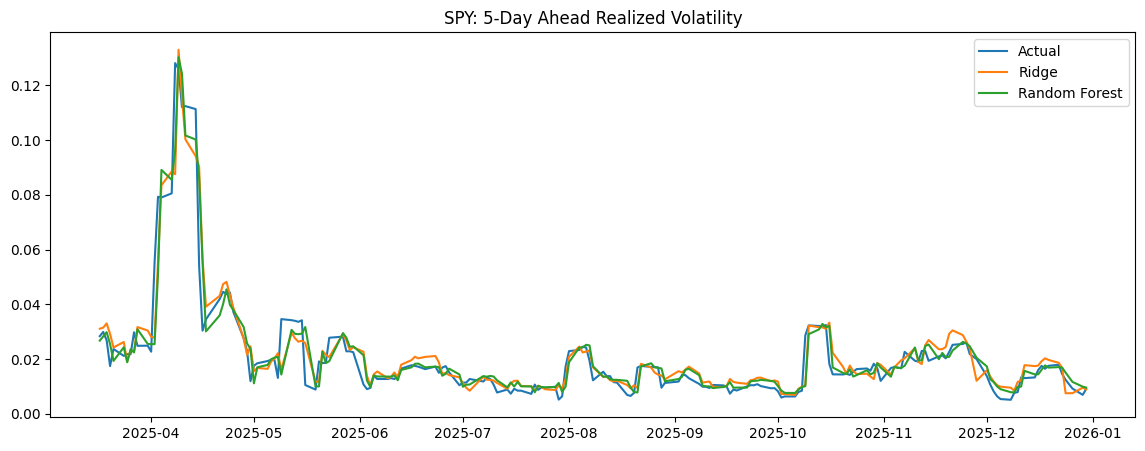

In [32]:
sample_plot = test_df[["Date", "ticker"]].copy()
sample_plot["actual_rv5"] = y_test_rv5
sample_plot["pred_ridge"] = test_pred_ridge
sample_plot["pred_rf"] = test_pred_rf

sample_asset = "SPY"
plot_df = sample_plot[sample_plot["ticker"] == sample_asset].sort_values("Date").tail(200)

plt.figure(figsize=(14, 5))
plt.plot(plot_df["Date"], plot_df["actual_rv5"], label="Actual")
plt.plot(plot_df["Date"], plot_df["pred_ridge"], label="Ridge")
plt.plot(plot_df["Date"], plot_df["pred_rf"], label="Random Forest")
plt.title(f"{sample_asset}: 5-Day Ahead Realized Volatility")
plt.legend()
plt.show()

In [33]:
train_seq_df = train_df.copy()
val_seq_df = val_df.copy()
test_seq_df = test_df.copy()

seq_scaler = StandardScaler()
train_seq_df[feature_cols] = seq_scaler.fit_transform(train_seq_df[feature_cols])
val_seq_df[feature_cols] = seq_scaler.transform(val_seq_df[feature_cols])
test_seq_df[feature_cols] = seq_scaler.transform(test_seq_df[feature_cols])

print(train_seq_df.shape, val_seq_df.shape, test_seq_df.shape)

(48510, 48) (16566, 48) (11022, 48)


In [34]:
class PanelSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, lookback=60):
        self.X = []
        self.y = []
        self.meta = []
        
        for ticker, g in df.groupby("ticker"):
            g = g.sort_values("Date").reset_index(drop=True)
            
            feat = g[feature_cols].values.astype(np.float32)
            targ = g[target_col].values.astype(np.float32)
            dates = g["Date"].values
            
            for i in range(lookback, len(g)):
                self.X.append(feat[i-lookback:i])
                self.y.append(targ[i])
                self.meta.append((ticker, dates[i]))
        
        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [35]:
lookback = 60

train_dataset_rv = PanelSequenceDataset(
    train_seq_df, feature_cols, target_col="future_rv_5", lookback=lookback
)
val_dataset_rv = PanelSequenceDataset(
    val_seq_df, feature_cols, target_col="future_rv_5", lookback=lookback
)
test_dataset_rv = PanelSequenceDataset(
    test_seq_df, feature_cols, target_col="future_rv_5", lookback=lookback
)

print("Train sequences:", len(train_dataset_rv))
print("Val sequences  :", len(val_dataset_rv))
print("Test sequences :", len(test_dataset_rv))

Train sequences: 47190
Val sequences  : 15246
Test sequences : 9702


In [36]:
x_sample, y_sample = train_dataset_rv[0]
print("X shape:", x_sample.shape)   # should be (lookback, num_features)
print("y value:", y_sample)

X shape: (60, 34)
y value: 0.025498183


In [37]:
train_loader = DataLoader(train_dataset_rv, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset_rv, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset_rv, batch_size=256, shuffle=False)

In [38]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.attn = nn.Linear(hidden_dim, 1)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        out, _ = self.lstm(x)                  # [B, T, H]
        attn_weights = torch.softmax(self.attn(out), dim=1)   # [B, T, 1]
        context = torch.sum(attn_weights * out, dim=1)        # [B, H]
        pred = self.fc(context).squeeze(-1)                   # [B]
        return pred

In [39]:
def train_lstm_regressor(model, train_loader, val_loader, epochs=15, lr=1e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    best_val_loss = np.inf
    best_state = None
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * xb.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                preds = model(xb)
                loss = criterion(preds, yb)
                running_val_loss += loss.item() * xb.size(0)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = model.state_dict()
    
    model.load_state_dict(best_state)
    return model, train_losses, val_losses

In [40]:
lstm_reg = LSTMRegressor(
    input_dim=len(feature_cols),
    hidden_dim=64,
    num_layers=2,
    dropout=0.2
)

lstm_reg, train_losses, val_losses = train_lstm_regressor(
    lstm_reg,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3
)

Epoch 01 | Train Loss: 0.000242 | Val Loss: 0.000252
Epoch 02 | Train Loss: 0.000168 | Val Loss: 0.000203
Epoch 03 | Train Loss: 0.000158 | Val Loss: 0.000194
Epoch 04 | Train Loss: 0.000149 | Val Loss: 0.000193
Epoch 05 | Train Loss: 0.000141 | Val Loss: 0.000178
Epoch 06 | Train Loss: 0.000135 | Val Loss: 0.000210
Epoch 07 | Train Loss: 0.000127 | Val Loss: 0.000173
Epoch 08 | Train Loss: 0.000120 | Val Loss: 0.000178
Epoch 09 | Train Loss: 0.000110 | Val Loss: 0.000142
Epoch 10 | Train Loss: 0.000101 | Val Loss: 0.000171
Epoch 11 | Train Loss: 0.000096 | Val Loss: 0.000143
Epoch 12 | Train Loss: 0.000091 | Val Loss: 0.000154
Epoch 13 | Train Loss: 0.000089 | Val Loss: 0.000150
Epoch 14 | Train Loss: 0.000084 | Val Loss: 0.000138
Epoch 15 | Train Loss: 0.000085 | Val Loss: 0.000132


In [41]:
def predict_regression(model, loader):
    model.eval()
    preds = []
    trues = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            out = model(xb).cpu().numpy()
            preds.extend(out)
            trues.extend(yb.numpy())
    
    return np.array(trues), np.array(preds)

In [42]:
y_val_true_lstm, y_val_pred_lstm = predict_regression(lstm_reg, val_loader)
y_test_true_lstm, y_test_pred_lstm = predict_regression(lstm_reg, test_loader)

regression_metrics(y_val_true_lstm, y_val_pred_lstm, "LSTM Validation")
regression_metrics(y_test_true_lstm, y_test_pred_lstm, "LSTM Test")

LSTM Validation
RMSE: 0.011475
MAE : 0.008188
R^2 : 0.628818
----------------------------------------
LSTM Test
RMSE: 0.014407
MAE : 0.008702
R^2 : 0.532521
----------------------------------------


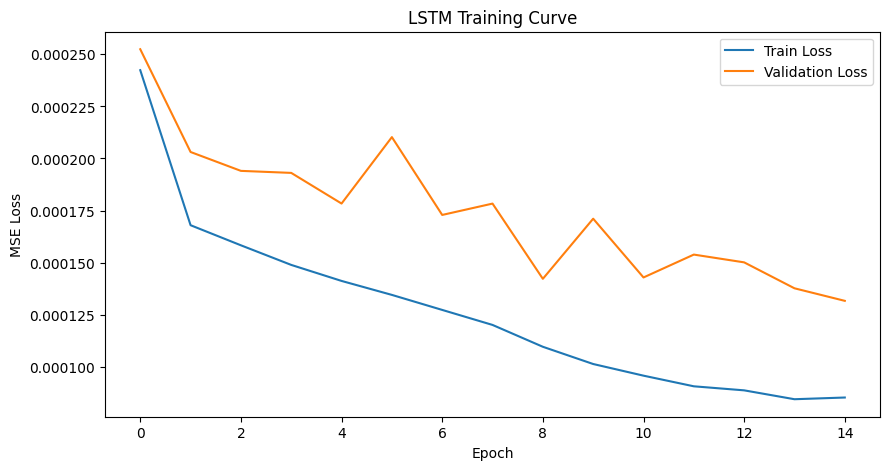

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

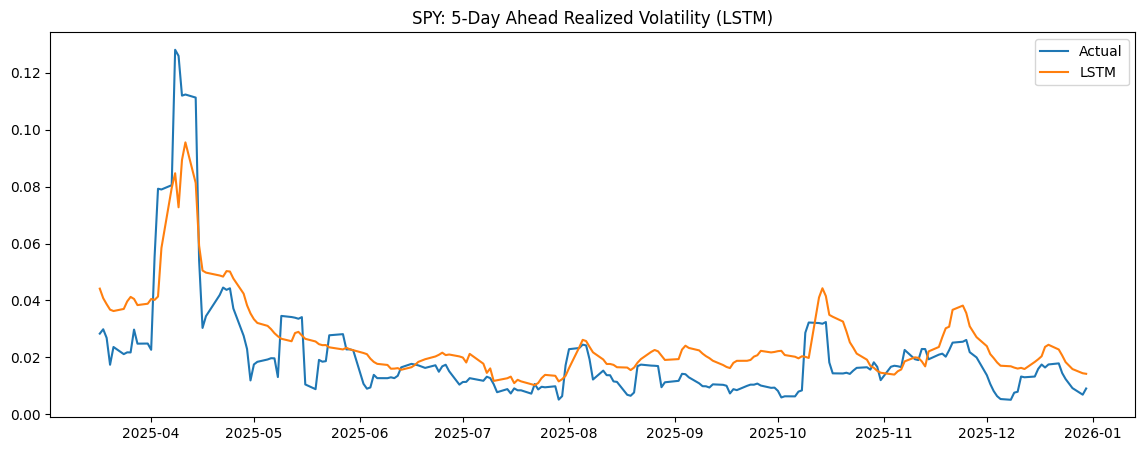

In [44]:
test_meta = pd.DataFrame(test_dataset_rv.meta, columns=["ticker", "Date"])
test_meta["Date"] = pd.to_datetime(test_meta["Date"])
test_meta["actual_rv5"] = y_test_true_lstm
test_meta["pred_lstm"] = y_test_pred_lstm

plot_lstm_df = test_meta[test_meta["ticker"] == "SPY"].sort_values("Date").tail(200)

plt.figure(figsize=(14, 5))
plt.plot(plot_lstm_df["Date"], plot_lstm_df["actual_rv5"], label="Actual")
plt.plot(plot_lstm_df["Date"], plot_lstm_df["pred_lstm"], label="LSTM")
plt.title("SPY: 5-Day Ahead Realized Volatility (LSTM)")
plt.legend()
plt.show()

In [45]:
summary_rows = []

def get_reg_metrics_dict(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

summary_rows.append(get_reg_metrics_dict(y_test_rv5, test_pred_ridge, "Ridge"))
summary_rows.append(get_reg_metrics_dict(y_test_rv5, test_pred_rf, "Random Forest"))
summary_rows.append(get_reg_metrics_dict(y_test_true_lstm, y_test_pred_lstm, "LSTM"))

summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,RMSE,MAE,R2
0,Ridge,0.008681,0.004951,0.821895
1,Random Forest,0.008695,0.004640,0.821335
2,LSTM,0.014407,0.008702,0.532521


In [46]:
summary_rows = []

def get_reg_metrics_dict(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

summary_rows.append(get_reg_metrics_dict(y_test_rv5, test_pred_ridge, "Ridge"))
summary_rows.append(get_reg_metrics_dict(y_test_rv5, test_pred_rf, "Random Forest"))
summary_rows.append(get_reg_metrics_dict(y_test_true_lstm, y_test_pred_lstm, "LSTM"))

summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,RMSE,MAE,R2
0,Ridge,0.008681,0.004951,0.821895
1,Random Forest,0.008695,0.004640,0.821335
2,LSTM,0.014407,0.008702,0.532521


In [47]:
multitask_targets = [
    "future_rv_5",
    "future_dsv_5",
    "future_score_5",
    "quality_label_5"
]

class MultiTaskPanelSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, target_cols, lookback=60):
        self.X = []
        self.y_reg = []
        self.y_cls = []
        self.meta = []
        
        reg_cols = ["future_rv_5", "future_dsv_5", "future_score_5"]
        cls_col = "quality_label_5"
        
        for ticker, g in df.groupby("ticker"):
            g = g.sort_values("Date").reset_index(drop=True)
            
            feat = g[feature_cols].values.astype(np.float32)
            y_reg = g[reg_cols].values.astype(np.float32)
            y_cls = g[cls_col].values.astype(np.float32)
            dates = g["Date"].values
            
            for i in range(lookback, len(g)):
                self.X.append(feat[i-lookback:i])
                self.y_reg.append(y_reg[i])
                self.y_cls.append(y_cls[i])
                self.meta.append((ticker, dates[i]))
        
        self.X = np.array(self.X, dtype=np.float32)
        self.y_reg = np.array(self.y_reg, dtype=np.float32)
        self.y_cls = np.array(self.y_cls, dtype=np.float32)
    
    def __len__(self):
        return len(self.y_cls)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y_reg[idx], self.y_cls[idx]

In [48]:
multitask_targets = [
    "future_rv_5",
    "future_dsv_5",
    "future_score_5",
    "quality_label_5"
]

class MultiTaskPanelSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, target_cols, lookback=60):
        self.X = []
        self.y_reg = []
        self.y_cls = []
        self.meta = []
        
        reg_cols = ["future_rv_5", "future_dsv_5", "future_score_5"]
        cls_col = "quality_label_5"
        
        for ticker, g in df.groupby("ticker"):
            g = g.sort_values("Date").reset_index(drop=True)
            
            feat = g[feature_cols].values.astype(np.float32)
            y_reg = g[reg_cols].values.astype(np.float32)
            y_cls = g[cls_col].values.astype(np.float32)
            dates = g["Date"].values
            
            for i in range(lookback, len(g)):
                self.X.append(feat[i-lookback:i])
                self.y_reg.append(y_reg[i])
                self.y_cls.append(y_cls[i])
                self.meta.append((ticker, dates[i]))
        
        self.X = np.array(self.X, dtype=np.float32)
        self.y_reg = np.array(self.y_reg, dtype=np.float32)
        self.y_cls = np.array(self.y_cls, dtype=np.float32)
    
    def __len__(self):
        return len(self.y_cls)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y_reg[idx], self.y_cls[idx]

In [49]:
train_dataset_mt = MultiTaskPanelSequenceDataset(
    train_seq_df, feature_cols, multitask_targets, lookback=lookback
)
val_dataset_mt = MultiTaskPanelSequenceDataset(
    val_seq_df, feature_cols, multitask_targets, lookback=lookback
)
test_dataset_mt = MultiTaskPanelSequenceDataset(
    test_seq_df, feature_cols, multitask_targets, lookback=lookback
)

print("Train multitask sequences:", len(train_dataset_mt))
print("Val multitask sequences  :", len(val_dataset_mt))
print("Test multitask sequences :", len(test_dataset_mt))

Train multitask sequences: 47190
Val multitask sequences  : 15246
Test multitask sequences : 9702


In [50]:
x_mt, y_reg_mt, y_cls_mt = train_dataset_mt[0]

print("X shape     :", x_mt.shape)
print("y_reg shape :", y_reg_mt.shape)
print("y_reg value :", y_reg_mt)
print("y_cls value :", y_cls_mt)

X shape     : (60, 34)
y_reg shape : (3,)
y_reg value : [ 0.02549818  0.0242267  -1.0405493 ]
y_cls value : 0.0


In [52]:
train_loader_mt = DataLoader(train_dataset_mt, batch_size=128, shuffle=True)
val_loader_mt = DataLoader(val_dataset_mt, batch_size=256, shuffle=False)
test_loader_mt = DataLoader(test_dataset_mt, batch_size=256, shuffle=False)

In [53]:
class MultiTaskLSTMAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.attn = nn.Linear(hidden_dim, 1)
        
        self.shared = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Regression heads
        self.rv_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
        self.dsv_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
        self.score_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
        # Classification head
        self.cls_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        out, _ = self.lstm(x)                           # [B, T, H]
        attn_weights = torch.softmax(self.attn(out), dim=1)
        context = torch.sum(attn_weights * out, dim=1) # [B, H]
        z = self.shared(context)                        # [B, 64]
        
        rv_pred = self.rv_head(z).squeeze(-1)
        dsv_pred = self.dsv_head(z).squeeze(-1)
        score_pred = self.score_head(z).squeeze(-1)
        cls_logit = self.cls_head(z).squeeze(-1)
        
        return rv_pred, dsv_pred, score_pred, cls_logit

In [54]:
def train_multitask_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=1e-3,
    w_rv=1.0,
    w_dsv=1.0,
    w_score=0.5,
    w_cls=1.0
):
    model = model.to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    bce_loss = nn.BCEWithLogitsLoss()
    
    best_val_loss = np.inf
    best_state = None
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        
        for xb, y_regb, y_clsb in train_loader:
            xb = xb.to(DEVICE)
            y_regb = y_regb.to(DEVICE)
            y_clsb = y_clsb.to(DEVICE)
            
            optimizer.zero_grad()
            
            rv_pred, dsv_pred, score_pred, cls_logit = model(xb)
            
            loss_rv = mse_loss(rv_pred, y_regb[:, 0])
            loss_dsv = mse_loss(dsv_pred, y_regb[:, 1])
            loss_score = mse_loss(score_pred, y_regb[:, 2])
            loss_cls = bce_loss(cls_logit, y_clsb)
            
            loss = (
                w_rv * loss_rv +
                w_dsv * loss_dsv +
                w_score * loss_score +
                w_cls * loss_cls
            )
            
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * xb.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for xb, y_regb, y_clsb in val_loader:
                xb = xb.to(DEVICE)
                y_regb = y_regb.to(DEVICE)
                y_clsb = y_clsb.to(DEVICE)
                
                rv_pred, dsv_pred, score_pred, cls_logit = model(xb)
                
                loss_rv = mse_loss(rv_pred, y_regb[:, 0])
                loss_dsv = mse_loss(dsv_pred, y_regb[:, 1])
                loss_score = mse_loss(score_pred, y_regb[:, 2])
                loss_cls = bce_loss(cls_logit, y_clsb)
                
                loss = (
                    w_rv * loss_rv +
                    w_dsv * loss_dsv +
                    w_score * loss_score +
                    w_cls * loss_cls
                )
                
                running_val_loss += loss.item() * xb.size(0)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = model.state_dict()
    
    model.load_state_dict(best_state)
    return model, train_losses, val_losses

In [55]:
mt_model = MultiTaskLSTMAttention(
    input_dim=len(feature_cols),
    hidden_dim=64,
    num_layers=2,
    dropout=0.2
)

mt_model, mt_train_losses, mt_val_losses = train_multitask_model(
    mt_model,
    train_loader_mt,
    val_loader_mt,
    epochs=20,
    lr=1e-3,
    w_rv=1.0,
    w_dsv=1.0,
    w_score=0.5,
    w_cls=1.0
)

Epoch 01 | Train Loss: 1.033917 | Val Loss: 1.050855
Epoch 02 | Train Loss: 1.006354 | Val Loss: 1.015621
Epoch 03 | Train Loss: 0.907465 | Val Loss: 0.836813
Epoch 04 | Train Loss: 0.756976 | Val Loss: 0.822404
Epoch 05 | Train Loss: 0.721179 | Val Loss: 0.772411
Epoch 06 | Train Loss: 0.697771 | Val Loss: 0.748611
Epoch 07 | Train Loss: 0.684806 | Val Loss: 0.764053
Epoch 08 | Train Loss: 0.677479 | Val Loss: 0.799336
Epoch 09 | Train Loss: 0.664365 | Val Loss: 0.773489
Epoch 10 | Train Loss: 0.655861 | Val Loss: 0.802340
Epoch 11 | Train Loss: 0.642241 | Val Loss: 0.948534
Epoch 12 | Train Loss: 0.632770 | Val Loss: 0.803297
Epoch 13 | Train Loss: 0.628409 | Val Loss: 0.848484
Epoch 14 | Train Loss: 0.616553 | Val Loss: 0.870306
Epoch 15 | Train Loss: 0.610489 | Val Loss: 0.850781
Epoch 16 | Train Loss: 0.596898 | Val Loss: 0.852926
Epoch 17 | Train Loss: 0.594107 | Val Loss: 0.878117
Epoch 18 | Train Loss: 0.582285 | Val Loss: 0.883566
Epoch 19 | Train Loss: 0.572953 | Val Loss: 0.

In [56]:
def predict_multitask(model, loader):
    model.eval()
    
    rv_preds, dsv_preds, score_preds, cls_probs = [], [], [], []
    y_reg_true, y_cls_true = [], []
    
    with torch.no_grad():
        for xb, y_regb, y_clsb in loader:
            xb = xb.to(DEVICE)
            
            rv_pred, dsv_pred, score_pred, cls_logit = model(xb)
            cls_prob = torch.sigmoid(cls_logit)
            
            rv_preds.extend(rv_pred.cpu().numpy())
            dsv_preds.extend(dsv_pred.cpu().numpy())
            score_preds.extend(score_pred.cpu().numpy())
            cls_probs.extend(cls_prob.cpu().numpy())
            
            y_reg_true.extend(y_regb.numpy())
            y_cls_true.extend(y_clsb.numpy())
    
    y_reg_true = np.array(y_reg_true)
    y_cls_true = np.array(y_cls_true)
    
    return {
        "rv_pred": np.array(rv_preds),
        "dsv_pred": np.array(dsv_preds),
        "score_pred": np.array(score_preds),
        "cls_prob": np.array(cls_probs),
        "y_reg_true": y_reg_true,
        "y_cls_true": y_cls_true
    }

In [57]:
val_mt = predict_multitask(mt_model, val_loader_mt)
test_mt = predict_multitask(mt_model, test_loader_mt)

print("Validation: future_rv_5")
regression_metrics(val_mt["y_reg_true"][:, 0], val_mt["rv_pred"], "MT-LSTM Validation RV")

print("Test: future_rv_5")
regression_metrics(test_mt["y_reg_true"][:, 0], test_mt["rv_pred"], "MT-LSTM Test RV")

print("Validation: future_dsv_5")
regression_metrics(val_mt["y_reg_true"][:, 1], val_mt["dsv_pred"], "MT-LSTM Validation DSV")

print("Test: future_dsv_5")
regression_metrics(test_mt["y_reg_true"][:, 1], test_mt["dsv_pred"], "MT-LSTM Test DSV")

print("Validation: future_score_5")
regression_metrics(val_mt["y_reg_true"][:, 2], val_mt["score_pred"], "MT-LSTM Validation Score")

print("Test: future_score_5")
regression_metrics(test_mt["y_reg_true"][:, 2], test_mt["score_pred"], "MT-LSTM Test Score")

val_cls_pred = (val_mt["cls_prob"] >= 0.5).astype(int)
test_cls_pred = (test_mt["cls_prob"] >= 0.5).astype(int)

print("Validation: quality_label_5")
classification_metrics(val_mt["y_cls_true"], val_cls_pred, val_mt["cls_prob"], "MT-LSTM Validation CLS")

print("Test: quality_label_5")
classification_metrics(test_mt["y_cls_true"], test_cls_pred, test_mt["cls_prob"], "MT-LSTM Test CLS")

Validation: future_rv_5
MT-LSTM Validation RV
RMSE: 0.015900
MAE : 0.011021
R^2 : 0.287379
----------------------------------------
Test: future_rv_5
MT-LSTM Test RV
RMSE: 0.019268
MAE : 0.011923
R^2 : 0.163782
----------------------------------------
Validation: future_dsv_5
MT-LSTM Validation DSV
RMSE: 0.013704
MAE : 0.009446
R^2 : 0.281651
----------------------------------------
Test: future_dsv_5
MT-LSTM Test DSV
RMSE: 0.016404
MAE : 0.010142
R^2 : 0.203371
----------------------------------------
Validation: future_score_5
MT-LSTM Validation Score
RMSE: 0.821390
MAE : 0.666957
R^2 : 0.312071
----------------------------------------
Test: future_score_5
MT-LSTM Test Score
RMSE: 0.825218
MAE : 0.672328
R^2 : 0.317295
----------------------------------------
Validation: quality_label_5
MT-LSTM Validation CLS
Accuracy : 0.761642
Precision: 0.607656
Recall   : 0.442098
F1       : 0.511822
ROC-AUC  : 0.788470
----------------------------------------
Test: quality_label_5
MT-LSTM Test C

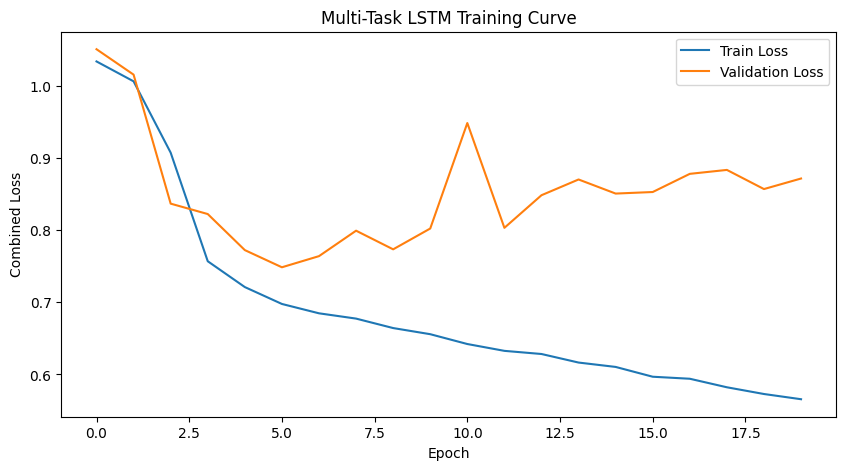

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(mt_train_losses, label="Train Loss")
plt.plot(mt_val_losses, label="Validation Loss")
plt.title("Multi-Task LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.legend()
plt.show()

In [59]:
mt_summary_rows = []

mt_summary_rows.append({
    "Model": "Ridge",
    "Task": "future_rv_5",
    "RMSE": np.sqrt(mean_squared_error(y_test_rv5, test_pred_ridge)),
    "MAE": mean_absolute_error(y_test_rv5, test_pred_ridge),
    "R2": r2_score(y_test_rv5, test_pred_ridge)
})

mt_summary_rows.append({
    "Model": "Random Forest",
    "Task": "future_rv_5",
    "RMSE": np.sqrt(mean_squared_error(y_test_rv5, test_pred_rf)),
    "MAE": mean_absolute_error(y_test_rv5, test_pred_rf),
    "R2": r2_score(y_test_rv5, test_pred_rf)
})

mt_summary_rows.append({
    "Model": "Single-Task LSTM",
    "Task": "future_rv_5",
    "RMSE": np.sqrt(mean_squared_error(y_test_true_lstm, y_test_pred_lstm)),
    "MAE": mean_absolute_error(y_test_true_lstm, y_test_pred_lstm),
    "R2": r2_score(y_test_true_lstm, y_test_pred_lstm)
})

mt_summary_rows.append({
    "Model": "Multi-Task LSTM",
    "Task": "future_rv_5",
    "RMSE": np.sqrt(mean_squared_error(test_mt["y_reg_true"][:, 0], test_mt["rv_pred"])),
    "MAE": mean_absolute_error(test_mt["y_reg_true"][:, 0], test_mt["rv_pred"]),
    "R2": r2_score(test_mt["y_reg_true"][:, 0], test_mt["rv_pred"])
})

mt_summary_df = pd.DataFrame(mt_summary_rows)
mt_summary_df

,Model,Task,RMSE,MAE,R2
0,Ridge,future_rv_5,0.008681,0.004951,0.821895
1,Random Forest,future_rv_5,0.008695,0.004640,0.821335
2,Single-Task LSTM,future_rv_5,0.014407,0.008702,0.532521
3,Multi-Task LSTM,future_rv_5,0.019268,0.011923,0.163782


In [60]:
cls_summary_rows = []

cls_summary_rows.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test_cls5, test_pred_logit),
    "Precision": precision_score(y_test_cls5, test_pred_logit, zero_division=0),
    "Recall": recall_score(y_test_cls5, test_pred_logit, zero_division=0),
    "F1": f1_score(y_test_cls5, test_pred_logit, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_cls5, test_prob_logit)
})

cls_summary_rows.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test_cls5, test_pred_rf_cls),
    "Precision": precision_score(y_test_cls5, test_pred_rf_cls, zero_division=0),
    "Recall": recall_score(y_test_cls5, test_pred_rf_cls, zero_division=0),
    "F1": f1_score(y_test_cls5, test_pred_rf_cls, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_cls5, test_prob_rf)
})

cls_summary_rows.append({
    "Model": "Multi-Task LSTM",
    "Accuracy": accuracy_score(test_mt["y_cls_true"], test_cls_pred),
    "Precision": precision_score(test_mt["y_cls_true"], test_cls_pred, zero_division=0),
    "Recall": recall_score(test_mt["y_cls_true"], test_cls_pred, zero_division=0),
    "F1": f1_score(test_mt["y_cls_true"], test_cls_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(test_mt["y_cls_true"], test_mt["cls_prob"])
})

cls_summary_df = pd.DataFrame(cls_summary_rows)
cls_summary_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.737797,0.550589,0.799882,0.652226,0.832199
1,Random Forest,0.790873,0.631528,0.767414,0.692871,0.862590
2,Multi-Task LSTM,0.754071,0.636086,0.427397,0.511266,0.775162


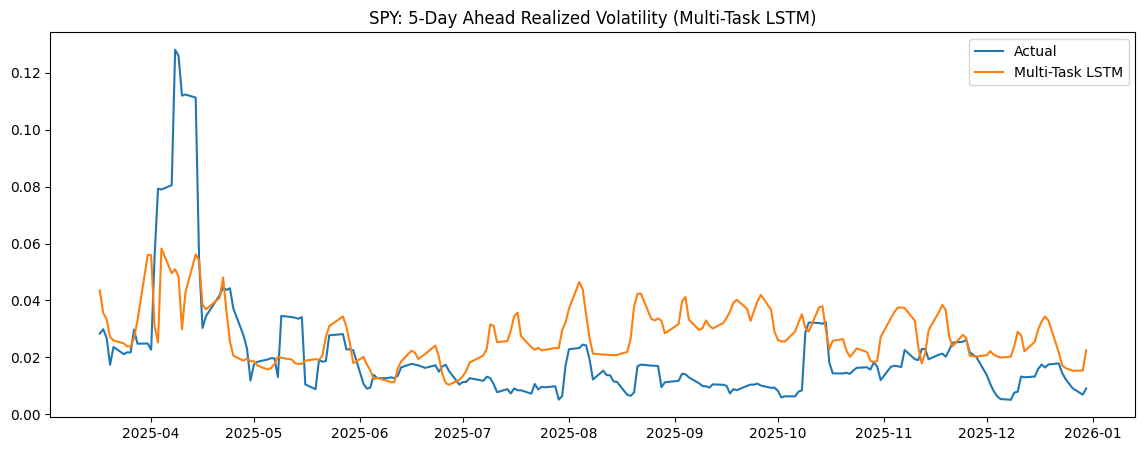

In [61]:
test_meta_mt = pd.DataFrame(test_dataset_mt.meta, columns=["ticker", "Date"])
test_meta_mt["Date"] = pd.to_datetime(test_meta_mt["Date"])
test_meta_mt["actual_rv5"] = test_mt["y_reg_true"][:, 0]
test_meta_mt["pred_mt_rv5"] = test_mt["rv_pred"]

plot_mt_df = test_meta_mt[test_meta_mt["ticker"] == "SPY"].sort_values("Date").tail(200)

plt.figure(figsize=(14, 5))
plt.plot(plot_mt_df["Date"], plot_mt_df["actual_rv5"], label="Actual")
plt.plot(plot_mt_df["Date"], plot_mt_df["pred_mt_rv5"], label="Multi-Task LSTM")
plt.title("SPY: 5-Day Ahead Realized Volatility (Multi-Task LSTM)")
plt.legend()
plt.show()

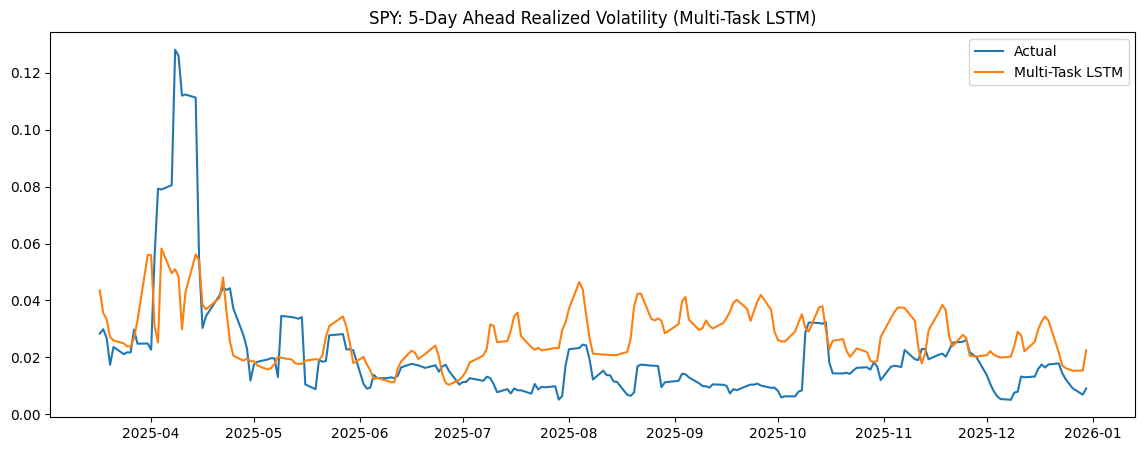

In [62]:
#FOR BETTER MULTIMODEL PERFORMANCE
test_meta_mt = pd.DataFrame(test_dataset_mt.meta, columns=["ticker", "Date"])
test_meta_mt["Date"] = pd.to_datetime(test_meta_mt["Date"])
test_meta_mt["actual_rv5"] = test_mt["y_reg_true"][:, 0]
test_meta_mt["pred_mt_rv5"] = test_mt["rv_pred"]

plot_mt_df = test_meta_mt[test_meta_mt["ticker"] == "SPY"].sort_values("Date").tail(200)

plt.figure(figsize=(14, 5))
plt.plot(plot_mt_df["Date"], plot_mt_df["actual_rv5"], label="Actual")
plt.plot(plot_mt_df["Date"], plot_mt_df["pred_mt_rv5"], label="Multi-Task LSTM")
plt.title("SPY: 5-Day Ahead Realized Volatility (Multi-Task LSTM)")
plt.legend()
plt.show()

In [63]:
mt_reg_cols = ["future_rv_5", "future_dsv_5", "future_score_5"]

target_means = train_df[mt_reg_cols].mean()
target_stds = train_df[mt_reg_cols].std().replace(0, 1.0)

print("Target means:")
print(target_means)
print("\nTarget stds:")
print(target_stds)

Target means:
future_rv_5       0.025582
future_dsv_5      0.015571
future_score_5    0.205778
dtype: float64

Target stds:
future_rv_5       0.020746
future_dsv_5      0.017180
future_score_5    0.976197
dtype: float64


In [64]:
train_mt_df = train_seq_df.copy()
val_mt_df = val_seq_df.copy()
test_mt_df = test_seq_df.copy()

for col in mt_reg_cols:
    train_mt_df[col + "_z"] = (train_mt_df[col] - target_means[col]) / target_stds[col]
    val_mt_df[col + "_z"] = (val_mt_df[col] - target_means[col]) / target_stds[col]
    test_mt_df[col + "_z"] = (test_mt_df[col] - target_means[col]) / target_stds[col]

train_mt_df[["future_rv_5", "future_rv_5_z", "future_dsv_5", "future_dsv_5_z", "future_score_5", "future_score_5_z"]].head()

,future_rv_5,future_rv_5_z,future_dsv_5,future_dsv_5_z,future_score_5,future_score_5_z
0,0.030944,0.258462,0.021227,0.329199,0.189189,-0.016994
1,0.040110,0.700276,0.021227,0.329199,0.473984,0.274746
2,0.041852,0.784207,0.021227,0.329199,0.570198,0.373306
3,0.042302,0.805925,0.022682,0.413898,0.254677,0.050091
4,0.043029,0.840983,0.018831,0.189746,0.890427,0.701343


In [66]:
class FixedMultiTaskPanelSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, lookback=60):
        self.X = []
        self.y_reg_z = []
        self.y_reg_raw = []
        self.y_cls = []
        self.meta = []
        
        reg_z_cols = ["future_rv_5_z", "future_dsv_5_z", "future_score_5_z"]
        reg_raw_cols = ["future_rv_5", "future_dsv_5", "future_score_5"]
        cls_col = "quality_label_5"
        
        for ticker, g in df.groupby("ticker"):
            g = g.sort_values("Date").reset_index(drop=True)
            
            feat = g[feature_cols].values.astype(np.float32)
            y_reg_z = g[reg_z_cols].values.astype(np.float32)
            y_reg_raw = g[reg_raw_cols].values.astype(np.float32)
            y_cls = g[cls_col].values.astype(np.float32)
            dates = g["Date"].values
            
            for i in range(lookback, len(g)):
                self.X.append(feat[i-lookback:i])
                self.y_reg_z.append(y_reg_z[i])
                self.y_reg_raw.append(y_reg_raw[i])
                self.y_cls.append(y_cls[i])
                self.meta.append((ticker, dates[i]))
        
        self.X = np.array(self.X, dtype=np.float32)
        self.y_reg_z = np.array(self.y_reg_z, dtype=np.float32)
        self.y_reg_raw = np.array(self.y_reg_raw, dtype=np.float32)
        self.y_cls = np.array(self.y_cls, dtype=np.float32)
    
    def __len__(self):
        return len(self.y_cls)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y_reg_z[idx], self.y_reg_raw[idx], self.y_cls[idx]

In [67]:
train_dataset_mt_fix = FixedMultiTaskPanelSequenceDataset(train_mt_df, feature_cols, lookback=lookback)
val_dataset_mt_fix = FixedMultiTaskPanelSequenceDataset(val_mt_df, feature_cols, lookback=lookback)
test_dataset_mt_fix = FixedMultiTaskPanelSequenceDataset(test_mt_df, feature_cols, lookback=lookback)

print("Train:", len(train_dataset_mt_fix))
print("Val  :", len(val_dataset_mt_fix))
print("Test :", len(test_dataset_mt_fix))

train_loader_mt_fix = DataLoader(train_dataset_mt_fix, batch_size=128, shuffle=True)
val_loader_mt_fix = DataLoader(val_dataset_mt_fix, batch_size=256, shuffle=False)
test_loader_mt_fix = DataLoader(test_dataset_mt_fix, batch_size=256, shuffle=False)

Train: 47190
Val  : 15246
Test : 9702


In [68]:
class FixedMultiTaskLSTMAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        
        self.attn = nn.Linear(hidden_dim, 1)
        
        self.shared = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.rv_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
        self.dsv_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
        self.score_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
        self.cls_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attn(out), dim=1)
        context = torch.sum(attn_weights * out, dim=1)
        z = self.shared(context)
        
        rv_pred_z = self.rv_head(z).squeeze(-1)
        dsv_pred_z = self.dsv_head(z).squeeze(-1)
        score_pred_z = self.score_head(z).squeeze(-1)
        cls_logit = self.cls_head(z).squeeze(-1)
        
        return rv_pred_z, dsv_pred_z, score_pred_z, cls_logit

In [69]:
def train_fixed_multitask_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=5e-4,
    w_rv=1.0,
    w_dsv=1.0,
    w_score=0.2,
    w_cls=1.0,
    patience=5
):
    model = model.to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    bce_loss = nn.BCEWithLogitsLoss()
    
    best_val_loss = np.inf
    best_state = None
    wait = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        
        for xb, y_reg_zb, y_reg_rawb, y_clsb in train_loader:
            xb = xb.to(DEVICE)
            y_reg_zb = y_reg_zb.to(DEVICE)
            y_clsb = y_clsb.to(DEVICE)
            
            optimizer.zero_grad()
            
            rv_pred_z, dsv_pred_z, score_pred_z, cls_logit = model(xb)
            
            loss_rv = mse_loss(rv_pred_z, y_reg_zb[:, 0])
            loss_dsv = mse_loss(dsv_pred_z, y_reg_zb[:, 1])
            loss_score = mse_loss(score_pred_z, y_reg_zb[:, 2])
            loss_cls = bce_loss(cls_logit, y_clsb)
            
            loss = (
                w_rv * loss_rv +
                w_dsv * loss_dsv +
                w_score * loss_score +
                w_cls * loss_cls
            )
            
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * xb.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for xb, y_reg_zb, y_reg_rawb, y_clsb in val_loader:
                xb = xb.to(DEVICE)
                y_reg_zb = y_reg_zb.to(DEVICE)
                y_clsb = y_clsb.to(DEVICE)
                
                rv_pred_z, dsv_pred_z, score_pred_z, cls_logit = model(xb)
                
                loss_rv = mse_loss(rv_pred_z, y_reg_zb[:, 0])
                loss_dsv = mse_loss(dsv_pred_z, y_reg_zb[:, 1])
                loss_score = mse_loss(score_pred_z, y_reg_zb[:, 2])
                loss_cls = bce_loss(cls_logit, y_clsb)
                
                loss = (
                    w_rv * loss_rv +
                    w_dsv * loss_dsv +
                    w_score * loss_score +
                    w_cls * loss_cls
                )
                
                running_val_loss += loss.item() * xb.size(0)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_state)
    return model, train_losses, val_losses

In [70]:
mt_fix_model = FixedMultiTaskLSTMAttention(
    input_dim=len(feature_cols),
    hidden_dim=32,
    num_layers=1,
    dropout=0.3
)

mt_fix_model, mt_fix_train_losses, mt_fix_val_losses = train_fixed_multitask_model(
    mt_fix_model,
    train_loader_mt_fix,
    val_loader_mt_fix,
    epochs=30,
    lr=5e-4,
    w_rv=1.0,
    w_dsv=1.0,
    w_score=0.2,
    w_cls=1.0,
    patience=5
)

Epoch 01 | Train Loss: 2.295773 | Val Loss: 2.132575
Epoch 02 | Train Loss: 1.734877 | Val Loss: 1.863177
Epoch 03 | Train Loss: 1.602242 | Val Loss: 1.814702
Epoch 04 | Train Loss: 1.521758 | Val Loss: 1.806932
Epoch 05 | Train Loss: 1.476559 | Val Loss: 1.899536
Epoch 06 | Train Loss: 1.423705 | Val Loss: 1.868456
Epoch 07 | Train Loss: 1.394270 | Val Loss: 1.714957
Epoch 08 | Train Loss: 1.352402 | Val Loss: 1.707481
Epoch 09 | Train Loss: 1.325372 | Val Loss: 1.733901
Epoch 10 | Train Loss: 1.311338 | Val Loss: 1.699515
Epoch 11 | Train Loss: 1.283812 | Val Loss: 1.767639
Epoch 12 | Train Loss: 1.264740 | Val Loss: 1.735626
Epoch 13 | Train Loss: 1.255590 | Val Loss: 1.751036
Epoch 14 | Train Loss: 1.240107 | Val Loss: 1.809927
Epoch 15 | Train Loss: 1.223704 | Val Loss: 1.752982
Early stopping at epoch 15


In [71]:
def predict_fixed_multitask(model, loader, target_means, target_stds):
    model.eval()
    
    rv_pred_z, dsv_pred_z, score_pred_z, cls_probs = [], [], [], []
    y_reg_raw_true, y_cls_true = [], []
    
    with torch.no_grad():
        for xb, y_reg_zb, y_reg_rawb, y_clsb in loader:
            xb = xb.to(DEVICE)
            
            rv_z, dsv_z, score_z, cls_logit = model(xb)
            cls_prob = torch.sigmoid(cls_logit)
            
            rv_pred_z.extend(rv_z.cpu().numpy())
            dsv_pred_z.extend(dsv_z.cpu().numpy())
            score_pred_z.extend(score_z.cpu().numpy())
            cls_probs.extend(cls_prob.cpu().numpy())
            
            y_reg_raw_true.extend(y_reg_rawb.numpy())
            y_cls_true.extend(y_clsb.numpy())
    
    rv_pred_z = np.array(rv_pred_z)
    dsv_pred_z = np.array(dsv_pred_z)
    score_pred_z = np.array(score_pred_z)
    
    rv_pred = rv_pred_z * target_stds["future_rv_5"] + target_means["future_rv_5"]
    dsv_pred = dsv_pred_z * target_stds["future_dsv_5"] + target_means["future_dsv_5"]
    score_pred = score_pred_z * target_stds["future_score_5"] + target_means["future_score_5"]
    
    return {
        "rv_pred": rv_pred,
        "dsv_pred": dsv_pred,
        "score_pred": score_pred,
        "cls_prob": np.array(cls_probs),
        "y_reg_true": np.array(y_reg_raw_true),
        "y_cls_true": np.array(y_cls_true)
    }

In [72]:
val_mt_fix = predict_fixed_multitask(mt_fix_model, val_loader_mt_fix, target_means, target_stds)
test_mt_fix = predict_fixed_multitask(mt_fix_model, test_loader_mt_fix, target_means, target_stds)

print("Validation: future_rv_5")
regression_metrics(val_mt_fix["y_reg_true"][:, 0], val_mt_fix["rv_pred"], "Fixed MT-LSTM Validation RV")

print("Test: future_rv_5")
regression_metrics(test_mt_fix["y_reg_true"][:, 0], test_mt_fix["rv_pred"], "Fixed MT-LSTM Test RV")

print("Validation: future_dsv_5")
regression_metrics(val_mt_fix["y_reg_true"][:, 1], val_mt_fix["dsv_pred"], "Fixed MT-LSTM Validation DSV")

print("Test: future_dsv_5")
regression_metrics(test_mt_fix["y_reg_true"][:, 1], test_mt_fix["dsv_pred"], "Fixed MT-LSTM Test DSV")

print("Validation: future_score_5")
regression_metrics(val_mt_fix["y_reg_true"][:, 2], val_mt_fix["score_pred"], "Fixed MT-LSTM Validation Score")

print("Test: future_score_5")
regression_metrics(test_mt_fix["y_reg_true"][:, 2], test_mt_fix["score_pred"], "Fixed MT-LSTM Test Score")

val_cls_fix_pred = (val_mt_fix["cls_prob"] >= 0.5).astype(int)
test_cls_fix_pred = (test_mt_fix["cls_prob"] >= 0.5).astype(int)

print("Validation: quality_label_5")
classification_metrics(val_mt_fix["y_cls_true"], val_cls_fix_pred, val_mt_fix["cls_prob"], "Fixed MT-LSTM Validation CLS")

print("Test: quality_label_5")
classification_metrics(test_mt_fix["y_cls_true"], test_cls_fix_pred, test_mt_fix["cls_prob"], "Fixed MT-LSTM Test CLS")

Validation: future_rv_5
Fixed MT-LSTM Validation RV
RMSE: 0.013988
MAE : 0.009437
R^2 : 0.448469
----------------------------------------
Test: future_rv_5
Fixed MT-LSTM Test RV
RMSE: 0.017240
MAE : 0.010538
R^2 : 0.330593
----------------------------------------
Validation: future_dsv_5
Fixed MT-LSTM Validation DSV
RMSE: 0.013432
MAE : 0.009355
R^2 : 0.309902
----------------------------------------
Test: future_dsv_5
Fixed MT-LSTM Test DSV
RMSE: 0.015852
MAE : 0.009892
R^2 : 0.256032
----------------------------------------
Validation: future_score_5
Fixed MT-LSTM Validation Score
RMSE: 0.947477
MAE : 0.780825
R^2 : 0.084662
----------------------------------------
Test: future_score_5
Fixed MT-LSTM Test Score
RMSE: 0.966681
MAE : 0.799609
R^2 : 0.063167
----------------------------------------
Validation: quality_label_5
Fixed MT-LSTM Validation CLS
Accuracy : 0.747344
Precision: 0.568475
Recall   : 0.440241
F1       : 0.496207
ROC-AUC  : 0.771707
-----------------------------------

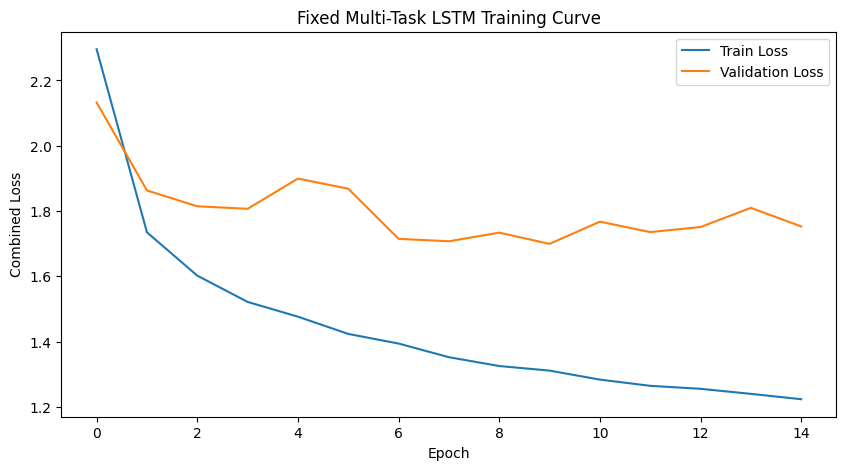

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(mt_fix_train_losses, label="Train Loss")
plt.plot(mt_fix_val_losses, label="Validation Loss")
plt.title("Fixed Multi-Task LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.legend()
plt.show()

In [74]:
mt_compare_rows = []

mt_compare_rows.append({
    "Model": "Old Multi-Task LSTM",
    "Task": "future_rv_5",
    "RMSE": np.sqrt(mean_squared_error(test_mt["y_reg_true"][:, 0], test_mt["rv_pred"])),
    "MAE": mean_absolute_error(test_mt["y_reg_true"][:, 0], test_mt["rv_pred"]),
    "R2": r2_score(test_mt["y_reg_true"][:, 0], test_mt["rv_pred"])
})

mt_compare_rows.append({
    "Model": "Fixed Multi-Task LSTM",
    "Task": "future_rv_5",
    "RMSE": np.sqrt(mean_squared_error(test_mt_fix["y_reg_true"][:, 0], test_mt_fix["rv_pred"])),
    "MAE": mean_absolute_error(test_mt_fix["y_reg_true"][:, 0], test_mt_fix["rv_pred"]),
    "R2": r2_score(test_mt_fix["y_reg_true"][:, 0], test_mt_fix["rv_pred"])
})

pd.DataFrame(mt_compare_rows)

,Model,Task,RMSE,MAE,R2
0,Old Multi-Task LSTM,future_rv_5,0.019268,0.011923,0.163782
1,Fixed Multi-Task LSTM,future_rv_5,0.017240,0.010538,0.330593


In [75]:
cls_compare_rows = []

cls_compare_rows.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test_cls5, test_pred_logit),
    "Precision": precision_score(y_test_cls5, test_pred_logit, zero_division=0),
    "Recall": recall_score(y_test_cls5, test_pred_logit, zero_division=0),
    "F1": f1_score(y_test_cls5, test_pred_logit, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_cls5, test_prob_logit)
})

cls_compare_rows.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test_cls5, test_pred_rf_cls),
    "Precision": precision_score(y_test_cls5, test_pred_rf_cls, zero_division=0),
    "Recall": recall_score(y_test_cls5, test_pred_rf_cls, zero_division=0),
    "F1": f1_score(y_test_cls5, test_pred_rf_cls, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_cls5, test_prob_rf)
})

cls_compare_rows.append({
    "Model": "Old Multi-Task LSTM",
    "Accuracy": accuracy_score(test_mt["y_cls_true"], test_cls_pred),
    "Precision": precision_score(test_mt["y_cls_true"], test_cls_pred, zero_division=0),
    "Recall": recall_score(test_mt["y_cls_true"], test_cls_pred, zero_division=0),
    "F1": f1_score(test_mt["y_cls_true"], test_cls_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(test_mt["y_cls_true"], test_mt["cls_prob"])
})

cls_compare_rows.append({
    "Model": "Fixed Multi-Task LSTM",
    "Accuracy": accuracy_score(test_mt_fix["y_cls_true"], test_cls_fix_pred),
    "Precision": precision_score(test_mt_fix["y_cls_true"], test_cls_fix_pred, zero_division=0),
    "Recall": recall_score(test_mt_fix["y_cls_true"], test_cls_fix_pred, zero_division=0),
    "F1": f1_score(test_mt_fix["y_cls_true"], test_cls_fix_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(test_mt_fix["y_cls_true"], test_mt_fix["cls_prob"])
})

pd.DataFrame(cls_compare_rows)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.737797,0.550589,0.799882,0.652226,0.832199
1,Random Forest,0.790873,0.631528,0.767414,0.692871,0.862590
2,Old Multi-Task LSTM,0.754071,0.636086,0.427397,0.511266,0.775162
3,Fixed Multi-Task LSTM,0.708308,0.520344,0.394178,0.448558,0.719722


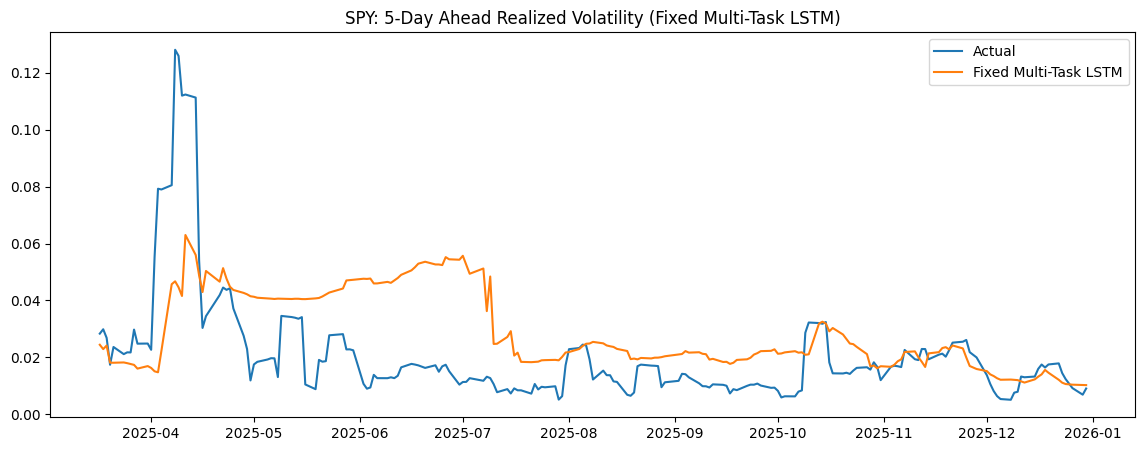

In [76]:
test_meta_mt_fix = pd.DataFrame(test_dataset_mt_fix.meta, columns=["ticker", "Date"])
test_meta_mt_fix["Date"] = pd.to_datetime(test_meta_mt_fix["Date"])
test_meta_mt_fix["actual_rv5"] = test_mt_fix["y_reg_true"][:, 0]
test_meta_mt_fix["pred_mt_fix_rv5"] = test_mt_fix["rv_pred"]

plot_mt_fix_df = test_meta_mt_fix[test_meta_mt_fix["ticker"] == "SPY"].sort_values("Date").tail(200)

plt.figure(figsize=(14, 5))
plt.plot(plot_mt_fix_df["Date"], plot_mt_fix_df["actual_rv5"], label="Actual")
plt.plot(plot_mt_fix_df["Date"], plot_mt_fix_df["pred_mt_fix_rv5"], label="Fixed Multi-Task LSTM")
plt.title("SPY: 5-Day Ahead Realized Volatility (Fixed Multi-Task LSTM)")
plt.legend()
plt.show()